<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-Defect-Detection-Experiments/OUR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [ ]:
train_dir = "/content/drive/MyDrive/NEW/new/NEU-DET/train"
val_dir   = "/content/drive/MyDrive/NEW/new/NEU-DET/val"

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

num_classes = len(train_generator.class_indices)

Found 1266 images belonging to 3 classes.
Found 614 images belonging to 3 classes.
{'annotations': 0, 'images': 1, 'labels': 2}


In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,411 (1.87 MB)

 Trainable params: 488,451 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_NEUDET_CNN.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7984 - loss: 0.4879
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/best_NEUDET_CNN.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_NEUDET_CNN.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 530s 13s/step - accuracy: 0.9265 - loss: 0.2191 - val_accuracy: 1.0000 - val_loss: 0.8454 - learning_rate: 1.0000e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9987 - loss: 0.0250
Epoch 2: val_accuracy did not improve from 1.00000
40/40 ━━━━━━━━━━━━━━━━━━━━ 327s 8s/step - accuracy: 0.9976 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.4440 - learning_rate: 1.0000e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9983 - loss: 0.0145
Epoch 3: val_accuracy did not improve from 1.00000
40/40 ━━━━━━━━━━━━━━━━━━━━ 308s 8s/step - accuracy: 0.9992 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.2420 - learning_rate: 1.0000e-04
Epoch 4/50
40/40 ━━━━━

In [ ]:
train_loss, train_acc = model.evaluate(train_generator)

val_loss, val_acc = model.evaluate(val_generator)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 1.0000 - loss: 1.4399e-06
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 1.0000 - loss: 1.6774e-06
Train Accuracy: 100.00%
Validation Accuracy: 100.00%


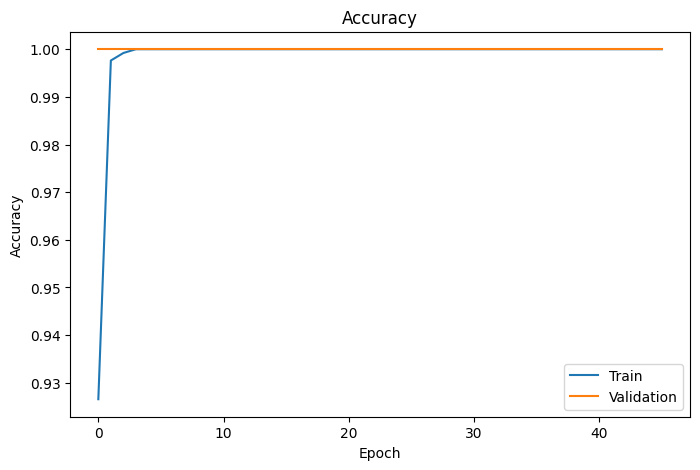

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

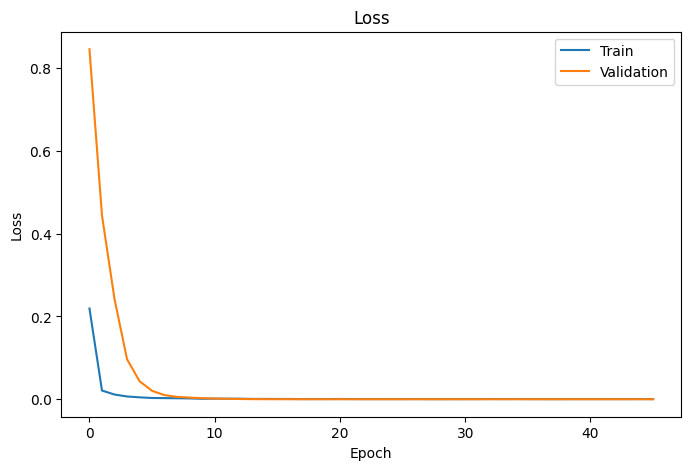

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
model.save(
    "/content/drive/MyDrive/NEUDET_Final_Model.keras"
)

print("Model Saved")

Model Saved


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


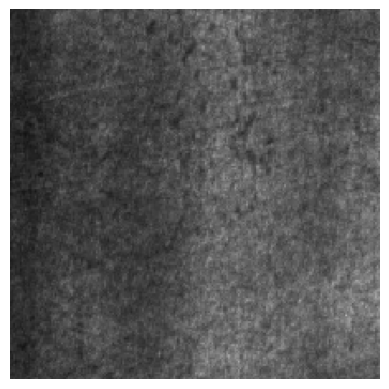

Prediction: inclusion
Confidence: 44.629646


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

model = load_model(
    "/content/drive/MyDrive/best_NEUDET_CNN.keras"
)

class_names = [
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled_in_scale',
    'scratches'
]

img_path = "/content/drive/MyDrive/NEW/new/NEU-DET/val/images/crazing_19.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)*100

plt.imshow(img)
plt.axis("off")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)